# **Laboratorio 05**
**Nombre:** Isabel Romero Caspary


### **Preparación previa**
Importamos las librerías y todo lo necesario para

In [67]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Configuramos el dispositivo GPU

In [69]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## **En base al Laboratorio 1: Regresión Lineal en Pytorch**
Utlizando el dataset:
Lattice-physics (PWR fuel assembly neutronics simulation results) obtenido de: https://archive.ics.uci.edu/dataset/1091/lattice-physics+(pwr+fuel+assembly+neutronics+simulation+results).

El archivo `raw.csv` contiene 24,000 instancias obtenidas de simulaciones neutrónicas de reactores nucleares. Tiene un total de 41 columnas Las primeras 40 columnas del dataset representan las características de entrada del sistema, como: el enriquecimiento del combustible, la densidad del moderador y la geometría del reactor, las cuales actúan como las variables predictoras. La columna restante (columna 0) representa el factor de multiplicación de neutrones ($k_{inf}$), que es el número que nos dice si un reactor nuclear es seguro y estable, este es el valor escalar objetivo a predecir mediante el modelo.

### **Carga y Preprocesamiento de Datos**

In [107]:
# Montamos el Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [108]:
# Cargar Datos
df = pd.read_csv('/content/drive/MyDrive/SIS420/raw.csv', sep=r'\s+', header=None)
data = df.values

X_L1 = data[:, 1:].astype(np.float32)   # características (columnas 1 en adelante)
y_L1 = data[:, 0].astype(np.float32)    # variable objetivo (columna 0)
print(df.shape)
print(df.head())


(24000, 41)
        0         1         2         3         4         5         6   \
0  1.32630  1.862086  3.562615  1.112359  4.208065  1.412679  2.271031   
1  1.34149  1.786558  2.354766  1.047929  2.268974  4.637777  3.793194   
2  1.33034  1.826187  3.037997  4.719517  1.502280  3.644736  3.575727   
3  1.35653  1.739225  4.412804  2.220680  3.132738  1.327124  4.759890   
4  1.30190  1.955829  2.790669  0.798177  1.231750  1.977844  2.393930   

         7         8         9   ...        31        32        33        34  \
0  3.950614  3.627032  4.600332  ...  3.965987  4.030999  0.826347  2.088521   
1  2.859702  4.361058  3.592485  ...  2.228000  4.837370  2.846538  3.413201   
2  1.337686  2.380347  4.503771  ...  2.615278  3.757999  3.161658  4.996056   
3  2.882082  3.663430  4.531524  ...  3.899026  1.018926  4.379308  3.280298   
4  4.738126  1.364743  3.391665  ...  3.641512  1.564076  2.178406  2.754888   

         35        36        37        38        39        40 

### **Normalización de Datos y Split**

Normalizamos los datos y determinamos los datos de entrenamiento `train` que serán el 80% y de prueba `test` que serán los otros 20%.

In [109]:
# Normalización
X_L1 = X_L1.astype(float)

X_L1_mean = X_L1.mean(axis=0)
X_L1_std  = X_L1.std(axis=0)
X_norm_L1 = (X_L1 - X_L1_mean) / X_L1_std

In [110]:
# split
m=y_L1.size
print(m)
m_train = int(0.8 * m)
print(m_train)
X_train_L1 = X_norm_L1[:m_train]
X_test_L1  = X_norm_L1[m_train:]
y_train_L1 = y_L1[:m_train]
y_test_L1  = y_L1[m_train:]

24000
19200


Convertimos todos los datos a tensores y los copiamos en el dispositivo, ya sea la gpu o cpu

In [111]:
X_t_train_L1 = torch.from_numpy(X_train_L1).float().to(device)
Y_t_train_L1  = torch.from_numpy(y_train_L1).float().to(device)

X_t_test_L1 = torch.from_numpy(X_test_L1).float().to(device)
Y_t_test_L1  = torch.from_numpy(y_test_L1).float().to(device)

### **Definición de Clases `Dataset` y `DataLoader`**

Para manejar los datos de manera eficiente en PyTorch, creamos una clase `Dataset` personalizada que hereda de `torch.utils.data.Dataset`. Esta clase nos permite acceder a los datos por índice y especifica el tamaño del conjunto de datos. Luego, utilizamos `DataLoader` para agrupar los datos en lotes (batches), mezclarlos y cargarlos de forma paralela durante el entrenamiento.

In [122]:
# Clase Dataset, hereda de la clase `torch.utils.data.Dataset`
class DatasetPersonalizado(torch.utils.data.Dataset):
    # constructor
    def __init__(self, X_tensor, Y_tensor):
        self.X = X_tensor
        # Para regresión, el tipo de dato de la variable objetivo (Y) debe ser float.
        self.Y = Y_tensor.float()

    # devolvemos el número de datos en el dataset
    def __len__(self):
        return len(self.X)

    # devolvemos el elemento `ix` del dataset
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]


In [123]:
# Creamos las instancias del Dataset para entrenamiento y prueba
train_dataset_L1 = DatasetPersonalizado(X_t_train_L1, Y_t_train_L1)
test_dataset_L1  = DatasetPersonalizado(X_t_test_L1, Y_t_test_L1)

print(f"Número de muestras en el dataset de entrenamiento: {len(train_dataset_L1)}")
print(f"Número de muestras en el dataset de prueba: {len(test_dataset_L1)}")


Número de muestras en el dataset de entrenamiento: 19200
Número de muestras en el dataset de prueba: 4800


In [114]:
# Configuramos el DataLoader
batch_size = 64 # valor ajustable según la memoria de tu GPU y el tamaño del modelo

train_dataloader_L1 = DataLoader(train_dataset_L1, batch_size=batch_size, shuffle=True)
test_dataloader_L1  = DataLoader(test_dataset_L1, batch_size=batch_size, shuffle=False) # No es necesario mezclar para la evaluación

# Verificamos la forma de un lote de datos
X_batch, Y_batch = next(iter(train_dataloader_L1))
print(f"Forma de X en un lote: {X_batch.shape}")
print(f"Forma de Y en un lote: {Y_batch.shape}")


Forma de X en un lote: torch.Size([64, 40])
Forma de Y en un lote: torch.Size([64])


### **Definición del modelo y de la Función de Pérdida y el Optimizador**

In [124]:
D_in  = X_batch.shape[1]  # Número de características de entrada (40)
H     = 100                # Número de neuronas en la capa oculta
D_out = 1                  # Una sola salida para la regresión (k_inf)

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
).to(device)

# Definimos la función de pérdida (MSELoss se usa para regresión)
criterion = torch.nn.MSELoss()

# Definimos el optimizador — Adam converge mejor que SGD para este dataset
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Modelo definido: {model}")

Modelo definido: Sequential(
  (0): Linear(in_features=40, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=1, bias=True)
)


In [125]:
D_in  = X_batch.shape[1]  # Número de características de entrada (40)
H1    = 100               # Número de neuronas en la primera capa oculta
H2    = 50                # Número de neuronas en la segunda capa oculta
D_out = 1                  # Una sola salida para la regresión (k_inf)

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H1),
    torch.nn.ReLU(),
    torch.nn.Linear(H1, H2),  # Nueva capa oculta
    torch.nn.ReLU(),
    torch.nn.Linear(H2, D_out),
).to(device)

# Definimos la función de pérdida (MSELoss se usa para regresión)
criterion = torch.nn.MSELoss()

# Definimos el optimizador — Adam converge mejor que SGD para este dataset
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Modelo definido: {model}")

Modelo definido: Sequential(
  (0): Linear(in_features=40, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=50, bias=True)
  (3): ReLU()
  (4): Linear(in_features=50, out_features=1, bias=True)
)


###**Entrenamiento**

In [126]:
epochs = 100
log_each = 1
l = []
model.train()
for e in range(1, epochs+1):

    _l = []
    # iteramos por batches en el dataloader
    for x_b, y_b in train_dataloader_L1:

        # forward
        y_pred_L1 = model(x_b)

        # loss
        loss = criterion(y_pred_L1, y_b)
        _l.append(loss.item())

        # ponemos a cero los gradientes
        optimizer.zero_grad()

        # Backprop (calculamos todos los gradientes automáticamente)
        loss.backward()

        # update de los pesos
        optimizer.step()

    l.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/100 Loss 0.07771
Epoch 2/100 Loss 0.04274
Epoch 3/100 Loss 0.03031
Epoch 4/100 Loss 0.02378
Epoch 5/100 Loss 0.01968
Epoch 6/100 Loss 0.01681
Epoch 7/100 Loss 0.01468
Epoch 8/100 Loss 0.01301
Epoch 9/100 Loss 0.01166
Epoch 10/100 Loss 0.01055
Epoch 11/100 Loss 0.00964
Epoch 12/100 Loss 0.00887
Epoch 13/100 Loss 0.00821
Epoch 14/100 Loss 0.00765
Epoch 15/100 Loss 0.00717
Epoch 16/100 Loss 0.00675
Epoch 17/100 Loss 0.00637
Epoch 18/100 Loss 0.00604
Epoch 19/100 Loss 0.00574
Epoch 20/100 Loss 0.00547
Epoch 21/100 Loss 0.00523
Epoch 22/100 Loss 0.00501
Epoch 23/100 Loss 0.00481
Epoch 24/100 Loss 0.00463
Epoch 25/100 Loss 0.00446
Epoch 26/100 Loss 0.00430
Epoch 27/100 Loss 0.00416
Epoch 28/100 Loss 0.00402
Epoch 29/100 Loss 0.00390
Epoch 30/100 Loss 0.00378
Epoch 31/100 Loss 0.00367
Epoch 32/100 Loss 0.00357
Epoch 33/100 Loss 0.00347
Epoch 34/100 Loss 0.00338
Epoch 35/100 Loss 0.00329
Epoch 36/100 Loss 0.00321
Epoch 37/100 Loss 0.00313
Epoch 38/100 Loss 0.00306
Epoch 39/100 Loss 0.0

Gráfica de Pérdida (Loss)

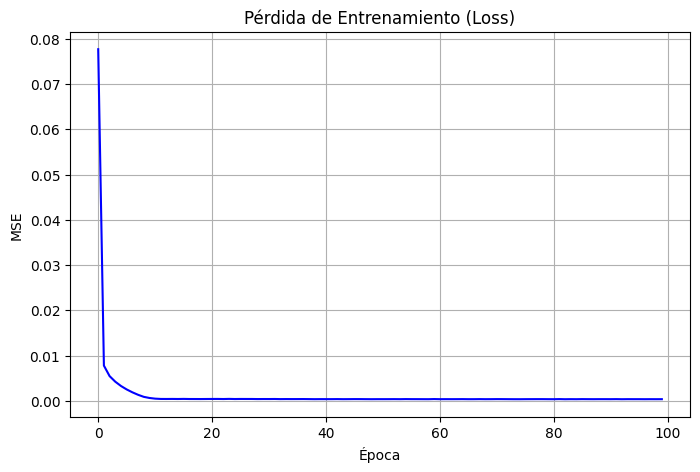

In [127]:
# Grafica la convergencia de la pérdida
plt.figure(figsize=(8, 5))
pyplot.plot(l, color='blue')
pyplot.title('Pérdida de Entrenamiento (Loss)')
pyplot.xlabel('Época'); pyplot.ylabel("MSE")
plt.grid(True)
plt.show()


### **Prueba del modelo**

In [128]:
from sklearn.metrics import mean_squared_error
model.eval()
with torch.no_grad():
    y_pred_test = model(torch.from_numpy(X_test_L1).float().to(device))

mse = mean_squared_error(y_test_L1, y_pred_test.cpu().numpy())
rmse = np.sqrt(mse)
print(f"\nRMSE en test: {rmse:.2f} µg/m³")


RMSE en test: 0.02 µg/m³


Gráfica de Predicciones

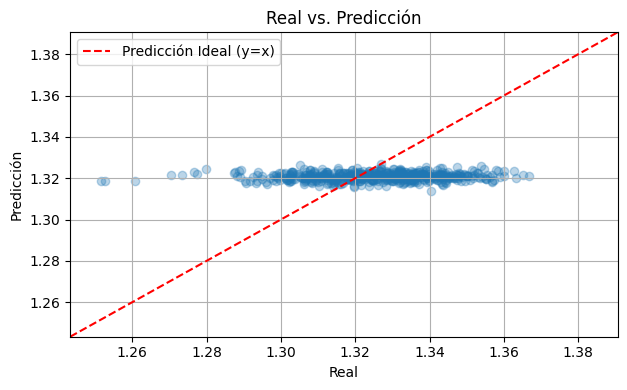

In [131]:
y_test_np = y_test_L1
y_pred_np = y_pred_test.cpu().numpy().flatten()

# Calcular el rango min/max de los datos reales y predichos
min_val = min(y_test_np.min(), y_pred_np.min())
max_val = max(y_test_np.max(), y_pred_np.max())

# Añadir un pequeño "padding" para una mejor visualización
padding = (max_val - min_val) * 0.1
plot_min = min_val - padding
plot_max = max_val + padding

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.scatter(y_test_np[:500], y_pred_np[:500], alpha=0.3)
plt.plot([plot_min, plot_max], [plot_min, plot_max], 'r--', label='Predicción Ideal (y=x)')
plt.title("Real vs. Predicción"); plt.xlabel("Real"); plt.ylabel("Predicción")
plt.xlim(plot_min, plot_max) # Establecer límites del eje X
plt.ylim(plot_min, plot_max) # Establecer límites del eje Y
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

In [133]:
print(f"\nEstadísticas de los Datos Reales (y_test_L1):")
print(f"  Mínimo: {y_test_L1.min():.5f}")
print(f"  Máximo: {y_test_L1.max():.5f}")
print(f"  Media: {y_test_L1.mean():.5f}")

print(f"\nEstadísticas de los Datos Predichos (y_pred_np):")
print(f"  Mínimo: {y_pred_np.min():.5f}")
print(f"  Máximo: {y_pred_np.max():.5f}")
print(f"  Media: {y_pred_np.mean():.5f}")



Estadísticas de los Datos Reales (y_test_L1):
  Mínimo: 1.24830
  Máximo: 1.38558
  Media: 1.32524

Estadísticas de los Datos Predichos (y_pred_np):
  Mínimo: 1.31378
  Máximo: 1.32872
  Media: 1.32086


Los valores reales como los predichos se encuentran en un rango muy estrecho. El modelo está haciendo un buen trabajo al predecir dentro de ese rango, que es donde se encuentran la gran mayoría de los datos reales.

## **En base al Laboratorio 3: Regresión Logística en Pytorch**
Utilizando el dataset:
Connect-4 obtenido de: https://archive.ics.uci.edu/dataset/26/connect+4.

Se creará un modelo de clasificación para predecir el resultado final de una partida de Connect-4. Suponga que está diseñando un sistema inteligente para analizar posiciones estratégicas en juegos de tablero y desea determinar las posibilidades de victoria del primer jugador en función del estado actual de las casillas. Disponemos de un dataset histórico con posiciones legales del juego tras 8 movimientos.

Para cada ejemplo de entrenamiento, se cuenta con la configuración de las fichas en el tablero (42 características seleccionadas) y el resultado final de la partida (victoria, derrota o empate). Por lo que, crearemos un modelo de clasificación que calcule la probabilidad de que una configuración específica del tablero resulte en una victoria para el jugador que inició la partida.

### **Carga y Preprocesamiento de Datos**

In [18]:
# Cargar Datos
# El archivo connect-4.data está separado por comas, sin cabecera.
# Las primeras 42 columnas son las posiciones del tablero (b, o, x)
# La última columna es el resultado (win, loss, draw)
df = pd.read_csv('/content/drive/MyDrive/SIS420/connect-4.csv', header=None)

# Convertimos los valores categóricos a numéricos
df.replace({'x': 1, 'o': -1, 'b': 0, 'win': 1, 'loss': 0, 'draw': 0}, inplace=True)
data = df.values.astype(np.float32)

X_L2 = data[:, :42]                  # 42 posiciones del tablero
y_L2 = data[:, 42].astype(np.int64)  # etiqueta: 1=victoria, 0=derrota/empate
print(df.shape)
print(df.head())

(67557, 43)
   0   1   2   3   4   5   6   7   8   9   ...  33  34  35  36  37  38  39  \
0   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
1   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
2   0   0   0   0   0   0  -1   0   0   0  ...   0   0   0   0   0   0   0   
3   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
4  -1   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   

   40  41  42  
0   0   0   1  
1   0   0   1  
2   0   0   1  
3   0   0   1  
4   0   0   1  

[5 rows x 43 columns]


/tmp/ipykernel_26898/3234440743.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'x': 1, 'o': -1, 'b': 0, 'win': 1, 'loss': 0, 'draw': 0}, inplace=True)


### **Normalización de Datos y Split**

Normalizamos los datos y determinamos los datos de entrenamiento `train` que serán el 80% y de prueba `test` que serán los otros 20%.

In [96]:
# Normalización
X_L2 = X_L2.astype(float)

X_L2_mean = X_L2.mean(axis=0)
X_L2_std  = X_L2.std(axis=0)
X_L2_std[X_L2_std == 0] = 1  # evitar división por cero en columnas constantes
X_norm_L2 = (X_L2 - X_L2_mean) / X_L2_std

In [97]:
# split
m = y_L2.size
print(m)
m_train = int(0.8 * m)
print(m_train)
X_train_L2 = X_norm_L2[:m_train]
X_test_L2  = X_norm_L2[m_train:]
y_train_L2 = y_L2[:m_train]
y_test_L2  = y_L2[m_train:]

67557
54045


Convertimos todos los datos a tensores y los copiamos en el dispositivo, ya sea la gpu o cpu

In [98]:
X_t_train_L2 = torch.from_numpy(X_train_L2).float().to(device)
Y_t_train_L2 = torch.from_numpy(y_train_L2).long().to(device)   # long para clasificación

X_t_test_L2 = torch.from_numpy(X_test_L2).float().to(device)
Y_t_test_L2 = torch.from_numpy(y_test_L2).long().to(device)

### **Definición de Clases `Dataset` y `DataLoader`**

Para manejar los datos de manera eficiente en PyTorch, creamos una clase `Dataset` personalizada que hereda de `torch.utils.data.Dataset`. Esta clase nos permite acceder a los datos por índice y especifica el tamaño del conjunto de datos. Luego, utilizamos `DataLoader` para agrupar los datos en lotes (batches), mezclarlos y cargarlos de forma paralela durante el entrenamiento.

In [99]:
# Clase Dataset, hereda de la clase `torch.utils.data.Dataset`
class DatasetPersonalizado(torch.utils.data.Dataset):
    # constructor
    def __init__(self, X_tensor, Y_tensor):
        self.X = X_tensor
        # Para clasificación, el tipo de dato de la variable objetivo (Y) debe ser long.
        self.Y = Y_tensor.long()

    # devolvemos el número de datos en el dataset
    def __len__(self):
        return len(self.X)

    # devolvemos el elemento `ix` del dataset
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

In [100]:
# Creamos las instancias del Dataset para entrenamiento y prueba
train_dataset_L2 = DatasetPersonalizado(X_t_train_L2, Y_t_train_L2)
test_dataset_L2  = DatasetPersonalizado(X_t_test_L2, Y_t_test_L2)

print(f"Número de muestras en el dataset de entrenamiento: {len(train_dataset_L2)}")
print(f"Número de muestras en el dataset de prueba: {len(test_dataset_L2)}")

Número de muestras en el dataset de entrenamiento: 54045
Número de muestras en el dataset de prueba: 13512


In [101]:
# Configuramos el DataLoader
batch_size = 64

train_dataloader_L2 = DataLoader(train_dataset_L2, batch_size=batch_size, shuffle=True)
test_dataloader_L2  = DataLoader(test_dataset_L2, batch_size=batch_size, shuffle=False)

# Verificamos la forma de un lote de datos
X_batch, Y_batch = next(iter(train_dataloader_L2))
print(f"Forma de X en un lote: {X_batch.shape}")
print(f"Forma de Y en un lote: {Y_batch.shape}")

Forma de X en un lote: torch.Size([64, 42])
Forma de Y en un lote: torch.Size([64])


### **Definición del modelo y de la Función de Pérdida y el Optimizador**

In [102]:
class ModeloPersonalizado(torch.nn.Module):

    def __init__(self, D_in, H, D_out):

        # llamamos al constructor de la clase madre
        super(ModeloPersonalizado, self).__init__()

        # definimos nuestras capas
        self.fc1 = torch.nn.Linear(D_in, H)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(H, D_out)

    # lógica para calcular las salidas de la red
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

D_in  = X_batch.shape[1]  # Número de características de entrada (42)
H     = 100                # Número de neuronas en la capa oculta
D_out = 2                  # 2 clases de salida: victoria (1) o derrota/empate (0)

# Instanciamos el modelo y lo movemos al dispositivo (GPU o CPU)
model_L2 = ModeloPersonalizado(D_in, H, D_out).to(device)

# Para clasificación usamos CrossEntropyLoss en lugar de MSELoss
criterion_L2 = torch.nn.CrossEntropyLoss()

# Definimos el optimizador
optimizer_L2 = optim.Adam(model_L2.parameters(), lr=0.003)

print(f"Modelo definido: {model_L2}")

Modelo definido: ModeloPersonalizado(
  (fc1): Linear(in_features=42, out_features=100, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)


### **Entrenamiento**

In [103]:
epochs = 200
log_each = 1
l = []
model_L2.train()
for e in range(1, epochs+1):

    _l = []
    # iteramos por batches en el dataloader
    for x_b, y_b in train_dataloader_L2:

        # forward
        y_pred_L2 = model_L2(x_b)

        # loss
        loss = criterion_L2(y_pred_L2, y_b)
        _l.append(loss.item())

        # ponemos a cero los gradientes
        optimizer_L2.zero_grad()

        # Backprop (calculamos todos los gradientes automáticamente)
        loss.backward()

        # update de los pesos
        optimizer_L2.step()

    l.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")

Epoch 1/200 Loss 0.39542
Epoch 2/200 Loss 0.37225
Epoch 3/200 Loss 0.35638
Epoch 4/200 Loss 0.34348
Epoch 5/200 Loss 0.33259
Epoch 6/200 Loss 0.32362
Epoch 7/200 Loss 0.31588
Epoch 8/200 Loss 0.30911
Epoch 9/200 Loss 0.30332
Epoch 10/200 Loss 0.29819
Epoch 11/200 Loss 0.29339
Epoch 12/200 Loss 0.28927
Epoch 13/200 Loss 0.28535
Epoch 14/200 Loss 0.28168
Epoch 15/200 Loss 0.27834
Epoch 16/200 Loss 0.27529
Epoch 17/200 Loss 0.27251
Epoch 18/200 Loss 0.26991
Epoch 19/200 Loss 0.26750
Epoch 20/200 Loss 0.26516
Epoch 21/200 Loss 0.26304
Epoch 22/200 Loss 0.26098
Epoch 23/200 Loss 0.25910
Epoch 24/200 Loss 0.25728
Epoch 25/200 Loss 0.25552
Epoch 26/200 Loss 0.25388
Epoch 27/200 Loss 0.25233
Epoch 28/200 Loss 0.25083
Epoch 29/200 Loss 0.24939
Epoch 30/200 Loss 0.24800
Epoch 31/200 Loss 0.24669
Epoch 32/200 Loss 0.24537
Epoch 33/200 Loss 0.24420
Epoch 34/200 Loss 0.24301
Epoch 35/200 Loss 0.24189
Epoch 36/200 Loss 0.24081
Epoch 37/200 Loss 0.23976
Epoch 38/200 Loss 0.23877
Epoch 39/200 Loss 0.2

Gráfica de Pérdida (Loss)

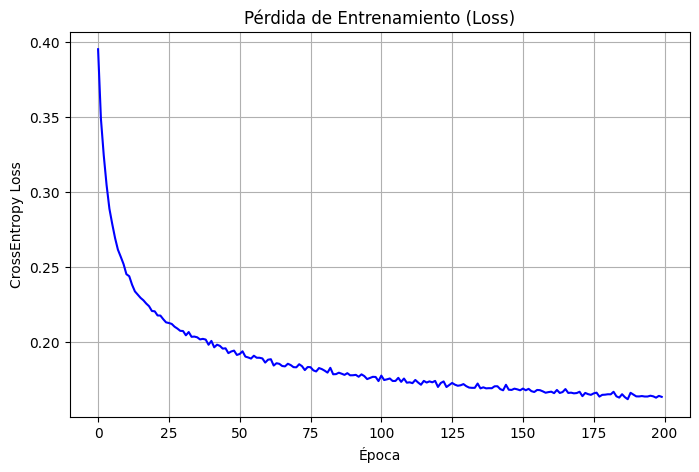

In [104]:
# Grafica la convergencia de la pérdida
plt.figure(figsize=(8, 5))
pyplot.plot(l, color='blue')
pyplot.title('Pérdida de Entrenamiento (Loss)')
pyplot.xlabel('Época'); pyplot.ylabel("CrossEntropy Loss")
plt.grid(True)
plt.show()

### **Prueba del modelo**

In [28]:
model_L2.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for x_b, y_b in test_dataloader_L2:
        y_pred_L2 = model_L2(x_b)
        preds = torch.argmax(y_pred_L2, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_b.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy en test: {acc*100:.2f}%")


Accuracy en test: 73.22%


Gráfica de Predicciones — Matriz de Confusión

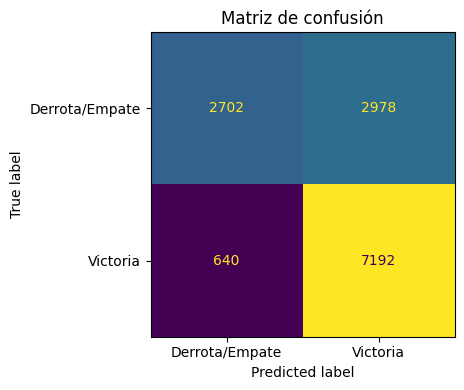

In [30]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 2)
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Derrota/Empate", "Victoria"])
disp.plot(ax=plt.gca(), colorbar=False)
plt.title("Matriz de confusión")

plt.tight_layout()
plt.show()

## **En base al Laboratorio 4: Clasificación One-vs-All en Pytorch**
Utilizando el dataset:
PAMAP2 Physical Activity Monitoring obtenido de: https://archive.ics.uci.edu/dataset/231/pamap2+physical+activity+monitoring.

Se creará un modelo de clasificación multiclase para reconocer actividades físicas a partir de datos de sensores inerciales (acelerómetro, giroscopio). El dataset contiene mediciones de 18 actividades físicas distintas (correr, caminar, subir escaleras, etc.) registradas con sensores colocados en la muñeca, el pecho y el tobillo.

Para cada ejemplo de entrenamiento, se cuenta con las mediciones de los sensores (52 características numéricas) y la etiqueta de la actividad realizada. Crearemos un modelo de clasificación que prediga qué actividad física está realizando el usuario a partir de los datos de los sensores.

### **Carga y Preprocesamiento de Datos**

In [33]:
# PAMAP2 se distribuye como archivos .dat separados por espacios, uno por sujeto.
# Cada fila tiene: timestamp, activityID, heartRate y 51 columnas de sensores.
# Cargamos y concatenamos los archivos de todos los sujetos disponibles.
import os

pamap2_path = '/content/drive/MyDrive/SIS420/Protocol'

columnas = ['timestamp', 'activityID', 'heartRate'] + [f'sensor_{i}' for i in range(1, 52)]

dfs = []
for archivo in sorted(os.listdir(pamap2_path)):
    if archivo.endswith('.dat'):
        # Usar os.path.join para construir la ruta completa del archivo correctamente
        df_suj = pd.read_csv(os.path.join(pamap2_path, archivo), sep=' ', header=None, names=columnas)
        dfs.append(df_suj)

df_pamap = pd.concat(dfs, ignore_index=True)
print(df_pamap.shape)
print(df_pamap.head())

(2872533, 54)
   timestamp  activityID  heartRate  sensor_1  sensor_2  sensor_3  sensor_4  \
0       8.38           0      104.0      30.0   2.37223   8.60074   3.51048   
1       8.39           0        NaN      30.0   2.18837   8.56560   3.66179   
2       8.40           0        NaN      30.0   2.37357   8.60107   3.54898   
3       8.41           0        NaN      30.0   2.07473   8.52853   3.66021   
4       8.42           0        NaN      30.0   2.22936   8.83122   3.70000   

   sensor_5  sensor_6  sensor_7  ...  sensor_42  sensor_43  sensor_44  \
0   2.43954   8.76165   3.35465  ...   0.008300   0.009250  -0.017580   
1   2.39494   8.55081   3.64207  ...  -0.006577  -0.004638   0.000368   
2   2.30514   8.53644   3.73280  ...   0.003014   0.000148   0.022495   
3   2.33528   8.53622   3.73277  ...   0.003175  -0.020301   0.011275   
4   2.23055   8.59741   3.76295  ...   0.012698  -0.014303  -0.002823   

   sensor_45  sensor_46  sensor_47  sensor_48  sensor_49  sensor_50  sen

In [34]:
# Eliminamos filas con actividad 0 (transición) y valores nulos
df_pamap = df_pamap[df_pamap['activityID'] != 0]
df_pamap = df_pamap.dropna()

# Las características son heartRate más las 51 columnas de sensores
feature_cols = ['heartRate'] + [f'sensor_{i}' for i in range(1, 52)]

X_L3     = df_pamap[feature_cols].values.astype(np.float32)
y_L3_raw = df_pamap['activityID'].values

# Re-etiquetamos las clases a índices 0..N-1 para CrossEntropyLoss
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_L3 = le.fit_transform(y_L3_raw).astype(np.int64)

print(f"Clases de actividad originales: {le.classes_}")
print(f"X shape: {X_L3.shape}, y shape: {y_L3.shape}")
print(f"Número de clases: {len(le.classes_)}")

Clases de actividad originales: [ 1  2  3  4  5  6  7 12 13 16 17 24]
X shape: (175498, 52), y shape: (175498,)
Número de clases: 12


### **Normalización de Datos y Split**

Normalizamos los datos y determinamos los datos de entrenamiento `train` que serán el 80% y de prueba `test` que serán los otros 20%.

In [35]:
# Normalización
X_L3 = X_L3.astype(float)

X_L3_mean = X_L3.mean(axis=0)
X_L3_std  = X_L3.std(axis=0)
X_L3_std[X_L3_std == 0] = 1  # evitar división por cero en columnas constantes
X_norm_L3 = (X_L3 - X_L3_mean) / X_L3_std

In [36]:
# split
m = y_L3.size
print(m)
m_train = int(0.8 * m)
print(m_train)
X_train_L3 = X_norm_L3[:m_train]
X_test_L3  = X_norm_L3[m_train:]
y_train_L3 = y_L3[:m_train]
y_test_L3  = y_L3[m_train:]

175498
140398


Convertimos todos los datos a tensores y los copiamos en el dispositivo, ya sea la gpu o cpu

In [37]:
X_t_train_L3 = torch.from_numpy(X_train_L3).float().to(device)
Y_t_train_L3 = torch.from_numpy(y_train_L3).long().to(device)   # long para clasificación

X_t_test_L3 = torch.from_numpy(X_test_L3).float().to(device)
Y_t_test_L3 = torch.from_numpy(y_test_L3).long().to(device)

### **Definición de Clases `Dataset` y `DataLoader`**

Para manejar los datos de manera eficiente en PyTorch, creamos una clase `Dataset` personalizada que hereda de `torch.utils.data.Dataset`. Esta clase nos permite acceder a los datos por índice y especifica el tamaño del conjunto de datos. Luego, utilizamos `DataLoader` para agrupar los datos en lotes (batches), mezclarlos y cargarlos de forma paralela durante el entrenamiento.

In [85]:
# Clase Dataset, hereda de la clase `torch.utils.data.Dataset`
class DatasetPersonalizado(torch.utils.data.Dataset):
    # constructor
    def __init__(self, X_tensor, Y_tensor):
        self.X = X_tensor
        # Para clasificación, el tipo de dato de la variable objetivo (Y) debe ser long.
        self.Y = Y_tensor.long()

    # devolvemos el número de datos en el dataset
    def __len__(self):
        return len(self.X)

    # devolvemos el elemento `ix` del dataset
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

In [86]:
# Creamos las instancias del Dataset para entrenamiento y prueba
train_dataset_L3 = DatasetPersonalizado(X_t_train_L3, Y_t_train_L3)
test_dataset_L3  = DatasetPersonalizado(X_t_test_L3, Y_t_test_L3)

print(f"Número de muestras en el dataset de entrenamiento: {len(train_dataset_L3)}")
print(f"Número de muestras en el dataset de prueba: {len(test_dataset_L3)}")

Número de muestras en el dataset de entrenamiento: 140398
Número de muestras en el dataset de prueba: 35100


In [87]:
# Configuramos el DataLoader
batch_size = 64

train_dataloader_L3 = DataLoader(train_dataset_L3, batch_size=batch_size, shuffle=True)
test_dataloader_L3  = DataLoader(test_dataset_L3, batch_size=batch_size, shuffle=False)

# Verificamos la forma de un lote de datos
X_batch, Y_batch = next(iter(train_dataloader_L3))
print(f"Forma de X en un lote: {X_batch.shape}")
print(f"Forma de Y en un lote: {Y_batch.shape}")

Forma de X en un lote: torch.Size([64, 52])
Forma de Y en un lote: torch.Size([64])


### **Definición del modelo y de la Función de Pérdida y el Optimizador**

In [88]:
class ModeloPersonalizado(torch.nn.Module):

    def __init__(self, D_in, H, D_out):

        # llamamos al constructor de la clase madre
        super(ModeloPersonalizado, self).__init__()

        # definimos nuestras capas
        self.fc1 = torch.nn.Linear(D_in, H)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(H, D_out)

    # lógica para calcular las salidas de la red
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

n_clases = len(le.classes_)   # número de actividades distintas detectadas
D_in  = X_batch.shape[1]      # Número de características de entrada (52)
H     = 100                    # Número de neuronas en la capa oculta
D_out = n_clases               # Una salida por cada actividad física

# Instanciamos el modelo y lo movemos al dispositivo (GPU o CPU)
model_L3 = ModeloPersonalizado(D_in, H, D_out).to(device)

# Para clasificación multiclase usamos CrossEntropyLoss
criterion_L3 = torch.nn.CrossEntropyLoss()

# Definimos el optimizador
optimizer_L3 = optim.Adagrad(model_L3.parameters(), lr=0.01)

print(f"Modelo definido: {model_L3}")

Modelo definido: ModeloPersonalizado(
  (fc1): Linear(in_features=52, out_features=100, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=100, out_features=12, bias=True)
)


### **Entrenamiento**

In [89]:
epochs = 100
log_each = 1
l = []
model_L3.train()
for e in range(1, epochs+1):

    _l = []
    # iteramos por batches en el dataloader
    for x_b, y_b in train_dataloader_L3:

        # forward
        y_pred_L3 = model_L3(x_b)

        # loss
        loss = criterion_L3(y_pred_L3, y_b)
        _l.append(loss.item())

        # ponemos a cero los gradientes
        optimizer_L3.zero_grad()

        # Backprop (calculamos todos los gradientes automáticamente)
        loss.backward()

        # update de los pesos
        optimizer_L3.step()

    l.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")

Epoch 1/100 Loss 0.45617
Epoch 2/100 Loss 0.36187
Epoch 3/100 Loss 0.31533
Epoch 4/100 Loss 0.28567
Epoch 5/100 Loss 0.26440
Epoch 6/100 Loss 0.24808
Epoch 7/100 Loss 0.23499
Epoch 8/100 Loss 0.22414
Epoch 9/100 Loss 0.21495
Epoch 10/100 Loss 0.20701
Epoch 11/100 Loss 0.20005
Epoch 12/100 Loss 0.19387
Epoch 13/100 Loss 0.18834
Epoch 14/100 Loss 0.18334
Epoch 15/100 Loss 0.17879
Epoch 16/100 Loss 0.17463
Epoch 17/100 Loss 0.17080
Epoch 18/100 Loss 0.16725
Epoch 19/100 Loss 0.16395
Epoch 20/100 Loss 0.16088
Epoch 21/100 Loss 0.15800
Epoch 22/100 Loss 0.15530
Epoch 23/100 Loss 0.15275
Epoch 24/100 Loss 0.15035
Epoch 25/100 Loss 0.14808
Epoch 26/100 Loss 0.14592
Epoch 27/100 Loss 0.14387
Epoch 28/100 Loss 0.14192
Epoch 29/100 Loss 0.14006
Epoch 30/100 Loss 0.13828
Epoch 31/100 Loss 0.13658
Epoch 32/100 Loss 0.13494
Epoch 33/100 Loss 0.13338
Epoch 34/100 Loss 0.13187
Epoch 35/100 Loss 0.13042
Epoch 36/100 Loss 0.12903
Epoch 37/100 Loss 0.12769
Epoch 38/100 Loss 0.12639
Epoch 39/100 Loss 0.1

Gráfica de Pérdida (Loss)

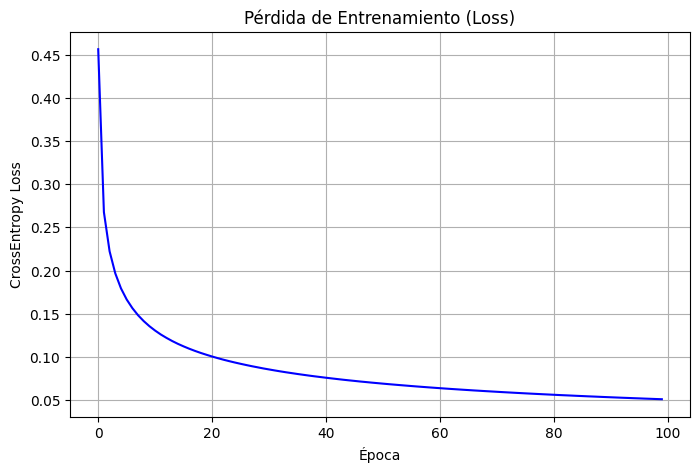

In [90]:
# Grafica la convergencia de la pérdida
plt.figure(figsize=(8, 5))
pyplot.plot(l, color='blue')
pyplot.title('Pérdida de Entrenamiento (Loss)')
pyplot.xlabel('Época'); pyplot.ylabel("CrossEntropy Loss")
plt.grid(True)
plt.show()

### **Prueba del modelo**

In [91]:
model_L3.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for x_b, y_b in test_dataloader_L3:
        y_pred_L3 = model_L3(x_b)
        preds = torch.argmax(y_pred_L3, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_b.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy en test: {acc*100:.2f}%")


Accuracy en test: 59.49%


Gráfica de Predicciones — Matriz de Confusión

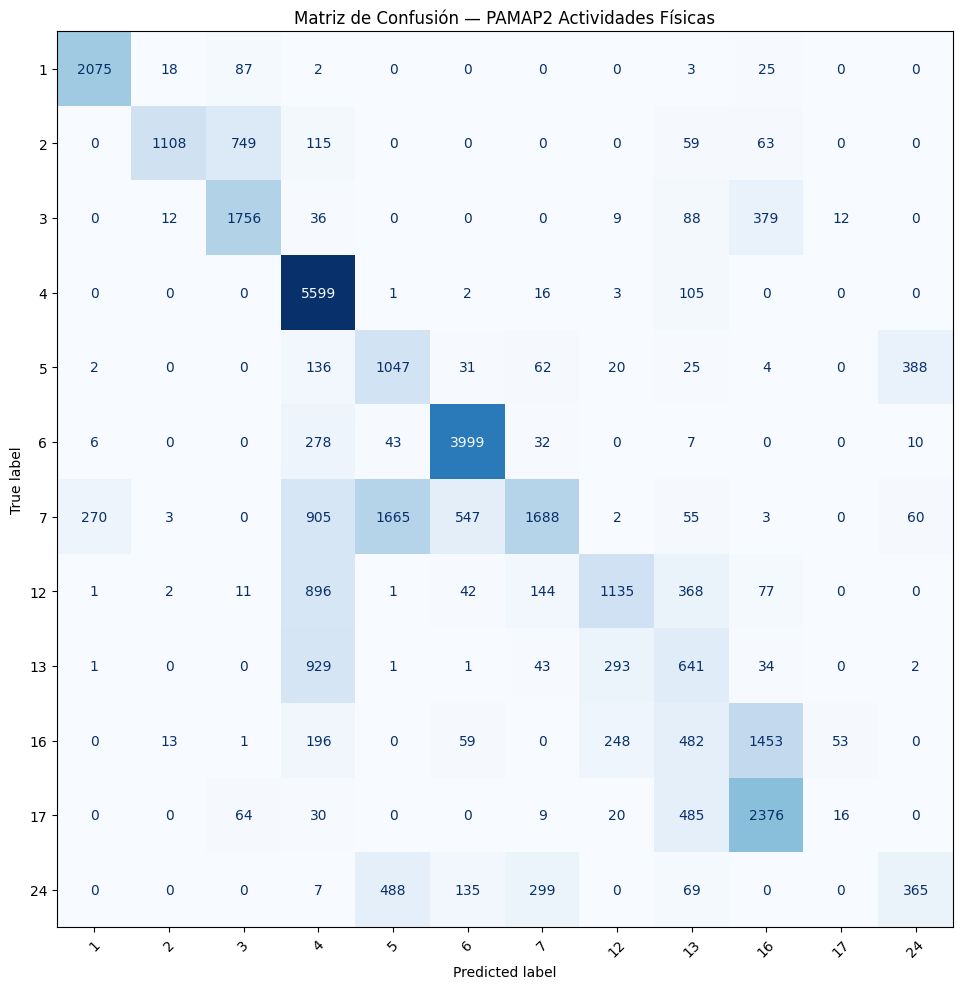

In [92]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
plt.title('Matriz de Confusión — PAMAP2 Actividades Físicas')
plt.grid(False)
plt.tight_layout()
plt.show()